# **Movie Success Analysis**
### **Spring 2026 CMSC320 Final Project**

## **Names:**  
- Pranav Samuel  

- Aarav Nirmal  

- Manan Rajput  

### Contributions
- **A: Project Idea** – 
- **B: Dataset Curation and Preprocessing** – 
- **C: Data Exploration and Summary Statistics** – 
- **D: ML Algorithm Design/Development** – 
- **E: ML Algorithm Training and Test Data Analysis** – 
- **F: Visualization, Result Analysis, Conclusion** –   
- **G: Final Tutorial Report Creation** –   


## **Introduction**

### **Motivation**
- The goal of this project is to explore which factors (such as budget, genre, popularity, and ratings) most strongly influence a movie’s financial and critical success.

### **Research Questions**
  - Does budget influence success?
  - Does director-writer overlap affect ratings?
  - Do certain genres earn more revenue?

### **Why This Matters**
- Financial risk in film industry
- Decision-making for studios


## **Data Curation and EDA**

### **Data Sources**
- TMDB 5000 Movie Metadata (Kaggle)  

- Worldwide Box Office Rankings (Kaggle)  
- CPI dataset (for inflation adjustment)

### **Imports**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob as glob
import json
from scipy.stats import chi2_contingency
import scipy.stats as stats
import seaborn as sns

### **Data Loading**

In this section, we import the datasets and inspect their structure. The next steps involve inspecting the structure of these datasets (columns, data types, missing values) to make sure they are ready for merging and analysis. The first two datasets are our list of 5000 movies with different information about the movies. The Consumer Price Index dataset is being loaded to adjust for inflation and thus, ensuring fair comparisons across different years.

`tmdb_movies` contains movie metadata (genres, budgets, revenues, ratings, etc.)  
`tmdb_credits` contains information about the cast and crew (directors, writers, actors, etc.)  
`cpi` contains monthly Consumer Price Index values from 1960-present

These datasets will later be merged to create a more comprehensive dataset for analysis.

In [ ]:
tmdb_movies = pd.read_csv("data/tmdb/tmdb_5000_movies.csv")
tmdb_credits = pd.read_csv("data/tmdb/tmdb_5000_credits.csv")

cpi = pd.read_csv("data/cpi/CORESTICKM159SFRBATL.csv")

### **Data Preprocessing**

In this section, we are going to clean and set up the data for analysis.

First, we are going to look into our revenues and adjust them according to inflation with our CPI dataset. We rename the columns in the CPI dataset for clarity. Then, we convert the date column to a datetime format, and the year is extracted to group CPI values by year. We finally calculate the average CPI each year to create a `yearly_cpi` dataset, which will be used to adjust revenue and budget values for inflation.

In [ ]:
# setting up cpi for grouping by year
cpi.columns = ["date", "cpi"]
cpi['date'] = pd.to_datetime(cpi['date'])
cpi['year'] = cpi['date'].dt.year
cpi['cpi'] = pd.to_numeric(cpi['cpi'], errors='coerce')

yearly_cpi = cpi.groupby('year')['cpi'].mean().reset_index()
yearly_cpi.head()

,year,cpi
0,1968,4.599479
1,1969,6.360164
2,1970,7.040731
3,1971,5.100820
4,1972,3.554771


Using `glob`, we load multiple box office revenue files and iterate through them.  

For each file:
- Extract the year from the filename
- Merge the dataset with our `yearly_cpi` dataset to get the CPI for the corresponding year
- Clean the `worldwide` revenue and convert it to numeric
- Apply the inflation-adjustment formula `revenue_adjusted = worldwide * (latest_cpi / cpi)`

We then combined all the datasets into a single `combined_movies` DataFrame and removed any unnecessary columns.

In [ ]:
# list all our files
movie_files = glob.glob("data/box_office/ranking_summary_*.csv")

adjusted_movies_list = []
latest_cpi = yearly_cpi['cpi'].iloc[-1]

# apply cpi to each file
for file in movie_files:
    df = pd.read_csv(file)
    
    # get the year from title
    year_from_file = int(file.split('_')[3].split('.')[0])
    df['year'] = year_from_file

    df = df.merge(yearly_cpi, on='year', how='left')
    
    # adjust for inflation
    df['worldwide'] = df['worldwide'].replace('[\\$,]', '', regex=True)
    df['worldwide'] = pd.to_numeric(df['worldwide'], errors='coerce')
    df['revenue_adjusted'] = df['worldwide'] * (latest_cpi / df['cpi'])
    
    # add each df to combine
    adjusted_movies_list.append(df)

combined_movies = pd.concat(adjusted_movies_list, ignore_index=True)
combined_movies = combined_movies.drop(columns=['rank','cpi', 'worldwide', 'domestic', 'domestic_pct', 'foreign', 'foreign_pct', 'year'])

combined_movies = combined_movies.dropna()
combined_movies


,title,revenue_adjusted
200,Avengers: Endgame,4.819614e+09
201,The Lion King,2.852653e+09
202,Frozen II,2.496418e+09
203,Spider-Man: Far from Home,1.948767e+09
204,Captain Marvel,1.942478e+09
...,...,...
9246,A Haunted House 2,5.573984e+07
9247,And So It Goes,5.563801e+07
9248,Kung Fu Jungle,5.290886e+07
9249,Hot Road,5.037131e+07


This step combines the metadata (`tmdb_movies`) and cast/crew information (`tmdb_credits`) into a single dataset (`tmdb_full`) based on `title`. By dropping unnecessary columns, we streamline the dataset, making it easier to work with making sure only relevant information is retained. This prepares the data for further preprocessing and merging.

In [ ]:
# merging our two tmdb datasets
tmdb_movies['title'] = tmdb_movies['title'].astype(str)
tmdb_credits['title'] = tmdb_credits['title'].astype(str)

tmdb_full = pd.merge(tmdb_movies, tmdb_credits, on='title', how='inner')

# dropping unnecessary columns
tmdb_full = tmdb_full.drop(columns=['id', 'tagline', 'status','overview', 'keywords', 'homepage', 'original_title', 'popularity', 'production_companies', 'production_countries', 'revenue', 'cast', 'spoken_languages'])
tmdb_full

,budget,genres,original_language,release_date,runtime,title,vote_average,vote_count,movie_id,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2009-12-10,162.0,Avatar,7.2,11800,19995,"[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",en,2007-05-19,169.0,Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2015-10-26,148.0,Spectre,6.3,4466,206647,"[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",en,2012-07-16,165.0,The Dark Knight Rises,7.6,9106,49026,"[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2012-03-07,132.0,John Carter,6.1,2124,49529,"[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
...,...,...,...,...,...,...,...,...,...,...
4804,220000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",es,1992-09-04,81.0,El Mariachi,6.6,238,9367,"[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de..."
4805,9000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",en,2011-12-26,85.0,Newlyweds,5.9,5,72766,"[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de..."
4806,0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",en,2013-10-13,120.0,"Signed, Sealed, Delivered",7.0,6,231617,"[{""credit_id"": ""52fe4df3c3a36847f8275ecf"", ""de..."
4807,0,[],en,2012-05-03,98.0,Shanghai Calling,5.7,7,126186,"[{""credit_id"": ""52fe4ad9c3a368484e16a36b"", ""de..."


Our next objective is to adjust the budget values in our `tmdb_full` dataset to account for inflation. We follow the same process we did for the revenues previously. We also drop the `cpi` and the original `budget` columns because they are no longer relevant. After adjusting the budget, we rearrange the columns to make it more organized.

In [ ]:
# adjust for budget with cpi (same process as before)
tmdb_full['release_date'] = pd.to_datetime(tmdb_full['release_date'])
tmdb_full['year'] = tmdb_full['release_date'].dt.year

tmdb_full = tmdb_full.merge(yearly_cpi, on='year', how='left')
tmdb_full['budget'] = pd.to_numeric(tmdb_full['budget'], errors='coerce')

tmdb_full['budget_adjusted'] = tmdb_full['budget'] * (latest_cpi / tmdb_full['cpi'])

# dropping cpi
tmdb_full = tmdb_full.drop(columns=['cpi', 'budget'])

# rearranging rows
tmdb_full = tmdb_full[['movie_id', 'title', 'genres','original_language', 'year', 'release_date', 'budget_adjusted','crew', 'vote_average', "vote_count"]]
tmdb_full

,movie_id,title,genres,original_language,year,release_date,budget_adjusted,crew,vote_average,vote_count
0,19995,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2009.0,2009-12-10,5.211635e+08,"[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.2,11800
1,285,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",en,2007.0,2007-05-19,4.727022e+08,"[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.9,4500
2,206647,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2015.0,2015-10-26,4.929587e+08,"[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.3,4466
3,49026,The Dark Knight Rises,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",en,2012.0,2012-07-16,5.002568e+08,"[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.6,9106
4,49529,John Carter,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2012.0,2012-03-07,5.202671e+08,"[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.1,2124
...,...,...,...,...,...,...,...,...,...,...
4804,9367,El Mariachi,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",es,1992.0,1992-09-04,2.533451e+05,"[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de...",6.6,238
4805,72766,Newlyweds,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",en,2011.0,2011-12-26,2.675839e+04,"[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de...",5.9,5
4806,231617,"Signed, Sealed, Delivered","[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",en,2013.0,2013-10-13,0.000000e+00,"[{""credit_id"": ""52fe4df3c3a36847f8275ecf"", ""de...",7.0,6
4807,126186,Shanghai Calling,[],en,2012.0,2012-05-03,0.000000e+00,"[{""credit_id"": ""52fe4ad9c3a368484e16a36b"", ""de...",5.7,7


We are merging the two datasets we have (`tmdb_full` and `combined_movies`). This will give us a holistic form of analysis of the movies. There are however certain issues with merging, for example movies which may not match (only in one of the databases) as well as having overlapping data. We overcome these issues by only choosing to take movies which are properly represented in both databases as well as taking priority of revenue information in the `combined_movies` database. 

In [ ]:
tmdb_full['title'] = tmdb_full['title'].astype(str).str.strip()
combined_movies['title'] = combined_movies['title'].astype(str).str.strip()

merged_movies = pd.merge(
    tmdb_full,
    combined_movies,
    on='title',
    how='inner'
)

merged_movies

,movie_id,title,genres,original_language,year,release_date,budget_adjusted,crew,vote_average,vote_count,revenue_adjusted
0,19995,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2009.0,2009-12-10,5.211635e+08,"[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.2,11800,6.033133e+09
1,285,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",en,2007.0,2007-05-19,4.727022e+08,"[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.9,4500,1.514217e+09
2,206647,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2015.0,2015-10-26,4.929587e+08,"[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.3,4466,1.771985e+09
3,49026,The Dark Knight Rises,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",en,2012.0,2012-07-16,5.002568e+08,"[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.6,9106,2.170993e+09
4,49529,John Carter,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,2012.0,2012-03-07,5.202671e+08,"[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.1,2124,5.685701e+08
...,...,...,...,...,...,...,...,...,...,...,...
3185,38780,Rampage,"[{""id"": 28, ""name"": ""Action""}, {""id"": 18, ""nam...",en,2009.0,2009-08-14,0.000000e+00,"[{""credit_id"": ""52fe46df9251416c91062979"", ""de...",6.0,131,7.690903e+08
3186,38780,Rampage,"[{""id"": 28, ""name"": ""Action""}, {""id"": 18, ""nam...",en,2009.0,2009-08-14,0.000000e+00,"[{""credit_id"": ""52fe46df9251416c91062979"", ""de...",6.0,131,9.170724e+05
3187,14022,Slacker,"[{""id"": 35, ""name"": ""Comedy""}]",en,1990.0,1990-07-27,0.000000e+00,"[{""credit_id"": ""52fe45c49251416c75061c17"", ""de...",6.4,77,1.082041e+06
3188,13898,The Circle,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10769, ""n...",fa,2000.0,2000-09-08,0.000000e+00,"[{""credit_id"": ""52fe45b09251416c7505f189"", ""de...",6.6,17,7.860143e+07


For our ANOVA test, we are testing how different genre categories contribute to box office success. In this step, we grouped genres into more general categories that we considered most important. For example, we mapped Action, Adventure, War, and Western to a new genre called Energy (higher-energy films). This will make it easier for the ANOVA hypothesis testing to find differences in box office revenues of the different genres. The different genres are the 5 new generic genres we have developed.

In [ ]:
merged_movies['genres'] = merged_movies['genres'].apply(
    lambda x: [g['name'] for g in json.loads(x)] if isinstance(x, str) else x
)

genre_map = {
    'Action': 'Energy', 'Adventure': 'Energy', 'War': 'Energy', 'Western': 'Energy',
    'Crime': 'Suspense', 'Mystery': 'Suspense', 'Thriller': 'Suspense', 'Horror': 'Suspense',
    'Science Fiction': 'Stylized', 'Fantasy': 'Stylized', 'Animation': 'Stylized',
    'Drama': 'Emotion and Experience', 'Romance': 'Emotion and Experience', 'History': 'Emotion and Experience', 'Documentary': 'Emotion and Experience',
    'Comedy': 'Lighthearted', 'Family': 'Lighthearted', 'Music': 'Lighthearted', 'TV Movie': 'Lighthearted'
}

merged_movies['genres'] = merged_movies['genres'].apply(
    lambda x: list(set(genre_map[g] for g in x if g in genre_map)) if isinstance(x, list) else x
)

merged_movies

,movie_id,title,genres,original_language,year,release_date,budget_adjusted,crew,vote_average,vote_count,revenue_adjusted
0,19995,Avatar,"[Stylized, Energy]",en,2009.0,2009-12-10,5.211635e+08,"[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.2,11800,6.033133e+09
1,285,Pirates of the Caribbean: At World's End,"[Stylized, Energy]",en,2007.0,2007-05-19,4.727022e+08,"[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.9,4500,1.514217e+09
2,206647,Spectre,"[Suspense, Energy]",en,2015.0,2015-10-26,4.929587e+08,"[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.3,4466,1.771985e+09
3,49026,The Dark Knight Rises,"[Suspense, Emotion and Experience, Energy]",en,2012.0,2012-07-16,5.002568e+08,"[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.6,9106,2.170993e+09
4,49529,John Carter,"[Stylized, Energy]",en,2012.0,2012-03-07,5.202671e+08,"[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.1,2124,5.685701e+08
...,...,...,...,...,...,...,...,...,...,...,...
3185,38780,Rampage,"[Suspense, Emotion and Experience, Energy]",en,2009.0,2009-08-14,0.000000e+00,"[{""credit_id"": ""52fe46df9251416c91062979"", ""de...",6.0,131,7.690903e+08
3186,38780,Rampage,"[Suspense, Emotion and Experience, Energy]",en,2009.0,2009-08-14,0.000000e+00,"[{""credit_id"": ""52fe46df9251416c91062979"", ""de...",6.0,131,9.170724e+05
3187,14022,Slacker,[Lighthearted],en,1990.0,1990-07-27,0.000000e+00,"[{""credit_id"": ""52fe45c49251416c75061c17"", ""de...",6.4,77,1.082041e+06
3188,13898,The Circle,[Emotion and Experience],fa,2000.0,2000-09-08,0.000000e+00,"[{""credit_id"": ""52fe45b09251416c7505f189"", ""de...",6.6,17,7.860143e+07


### **Hypothesis Testing**

#### ***TEST 1: Production Efficiency (Chi-Square)***

We use a chi-squared test of independence to determine whether a movie’s budget category (high vs. low) is related to its outcome (success vs. flop). Since both variables are categorical, this test is appropriate for checking whether there is an association between them or if they are independent. First, we clean the data by removing rows with missing budget or revenue values. We then split movies into “High” and “Low” budget groups based on the median budget, converting a numerical variable into a categorical one. Next, we classify each movie as a “Success” if its revenue exceeds its budget, and a “Flop” otherwise. Using these two categorical variables, we construct a contingency table that shows the counts of movies in each combination of budget category and outcome. Finally, we convert the counts into proportions and visualize them with a stacked bar chart to better interpret any differences between the groups.

outcome          Flop  Success
budget_category               
High              361     1231
Low               211     1379
Chi2: 47.09100894036773
p-value: 6.776583830581104e-12


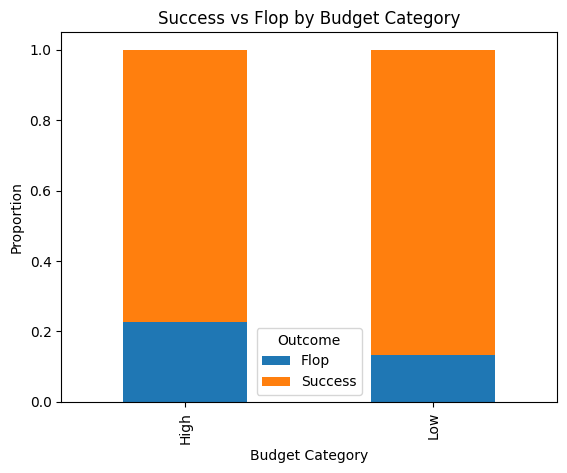

In [ ]:
df = merged_movies.dropna(subset=['budget_adjusted', 'revenue_adjusted'])

# high is the upper 50% and low is the lower 50%
median_budget = df['budget_adjusted'].median()

df['budget_category'] = df['budget_adjusted'].apply(
    lambda x: 'High' if x >= median_budget else 'Low'
)

# success if revenue > budget
df['outcome'] = df.apply(
    lambda row: 'Success' if row['revenue_adjusted'] > row['budget_adjusted'] else 'Flop',
    axis=1
)

# create contingency table
contingency_table = pd.crosstab(df['budget_category'], df['outcome'])
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi2:", chi2)
print("p-value:", p)

# convert to proportions
prop_table = contingency_table.div(contingency_table.sum(axis=1), axis=0)

# plot to stacked bar chart
prop_table.plot(kind='bar', stacked=True)

plt.title("Success vs Flop by Budget Category")
plt.ylabel("Proportion")
plt.xlabel("Budget Category")
plt.legend(title="Outcome")
plt.show()

The results of the chi-squared test show a test statistic of 47.09 and a p-value of 6.78 × 10⁻¹², which is far below any common significance level (e.g., α = 0.05). Therefore, we **reject the null hypothesis** and conclude that there is a statistically significant association between budget category and movie outcome. This suggests that a film’s budget level does have an impact on its likelihood of success. Looking at the contingency table, high-budget movies have more total flops than low-budget films, but they also have a substantially higher number of successes. When considering proportions, *high-budget films appear more likely to succeed compared to low-budget films*. This indicates that while higher budgets come with greater absolute risk, they are also associated with a **higher probability of financial success** overall.

#### ***TEST 2: Comparison of Means (Two-Sample T Test)***

In this analysis, we investigate whether movies where the director and writer are the same person differ in audience reception compared to movies where these roles are handled by different individuals. We categorize each movie based on the overlap between directors and writers, creating two groups: “Same Person” for films where at least one individual serves as both director and writer, and “Different People” for films where the roles are separate. Using the average vote rating (`vote_average`) as a measure of audience response, we compare these two groups with a two-sample t-test, which evaluates whether the mean ratings of the two independent groups are significantly different. This approach allows us to determine whether any observed difference in ratings is likely due to random variation or reflects a meaningful pattern associated with director-writer overlap.

Same Person: 1157 6.449265341400173 0.8652518662157186
Different People: 2033 6.153812100344319 0.8300557791896326
T-stat: 9.409266982604862
p-value: 1.1593381733263598e-20


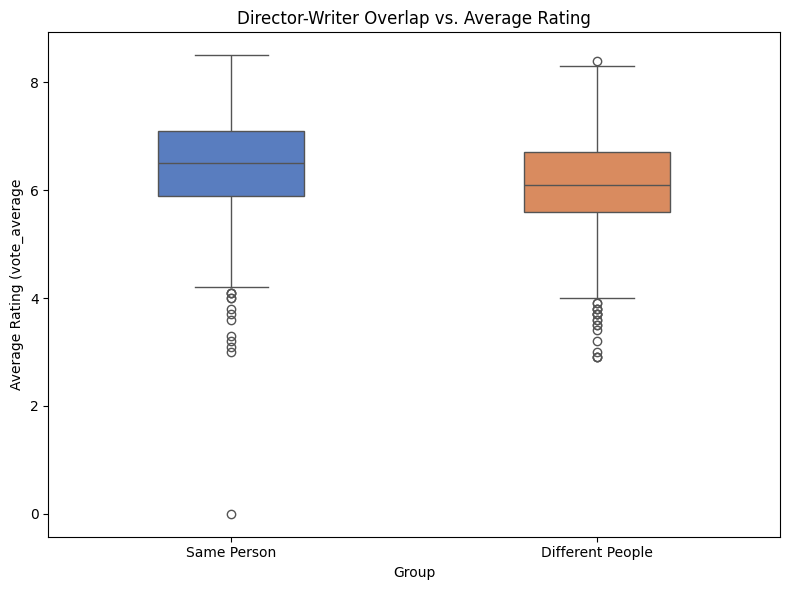

In [ ]:
df = merged_movies.dropna(subset=['crew', 'vote_average']).copy()

# parse once
df['crew'] = df['crew'].apply(lambda c: json.loads(c) if isinstance(c, str) else c)

# get directors and writers
df['directors'] = df['crew'].apply(
    lambda c: {m['name'] for m in c if m.get('job') == 'Director'}
)

df['writers'] = df['crew'].apply(
    lambda c: {m['name'] for m in c if m.get('department') == 'Writing'}
)

# categorize overlap
df['overlap'] = df.apply(
    lambda row: 'Same Person' if len(row['directors'] & row['writers']) > 0 else 'Different People',
    axis=1
)

# split groups
group_a = df[df['overlap'] == 'Same Person']['vote_average']
group_b = df[df['overlap'] == 'Different People']['vote_average']

# summary stats
print("Same Person:", len(group_a), group_a.mean(), group_a.std())
print("Different People:", len(group_b), group_b.mean(), group_b.std())

# t-test
t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)
print("T-stat:", t_stat)
print("p-value:", p_value)

# boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='overlap', y='vote_average', palette = 'muted', hue = 'overlap', width=0.4)
plt.title("Director-Writer Overlap vs. Average Rating")
plt.xlabel("Group")
plt.ylabel("Average Rating (vote_average")
plt.tight_layout()
plt.show()

A two-sample t-test was conducted to compare the mean average rating of movies in which the director is also a writer (Group A) with those in which the director is a separate specialist (Group B). The results were statistically significant (t = 9.46, p < 0.001), leading us to reject the null hypothesis that the two group means are equal.

Movies with a director-writer overlap had a **higher mean rating** (6.45, n = 1162) compared to those with separate specialists (6.15, n = 2044). This suggests that a *singular creative vision is associated with decently higher audience ratings*. However, the practical difference is roughly 0.3 points on a 10-point scale, so while the effect is statistically significant, the real-world impact on perceived quality is relatively small.

#### ***TEST 3: Market Analaysis: ANOVA - 5 Genres vs. Box Office Revenue*** 

We ran an ANOVA test with 5 notable buckets of genre types. We did this as there are significant types of movies of different types, so we wanted to see the relationship between these genre types and how they fared in the market.

We did this by first exploding the genres in the spreadsheet, that is, creating n duplicates for each n number of genre types the movie was. We did this so that an action-comedy movie like Deadpool would be considered as both a lighthearted and a high-energy movie. We then compared the worldwide revenue for each genre category by grouping the exploded dataset and calculating the mean adjusted revenue for each of the five buckets. This approach allowed us to account for the multi-faceted nature of modern films, ensuring that a single "Blockbuster" contributes its financial data to every thematic category it represents.

Genre Category: Emotion and Experience    | Number of Movies: 1618
Genre Category: Lighthearted              | Number of Movies: 1392
Genre Category: Suspense                  | Number of Movies: 1290
Genre Category: Energy                    | Number of Movies: 1228
Genre Category: Stylized                  | Number of Movies: 825
ANOVA F-Statistic: 72.9914
ANOVA P-Value: 1.4558e-60


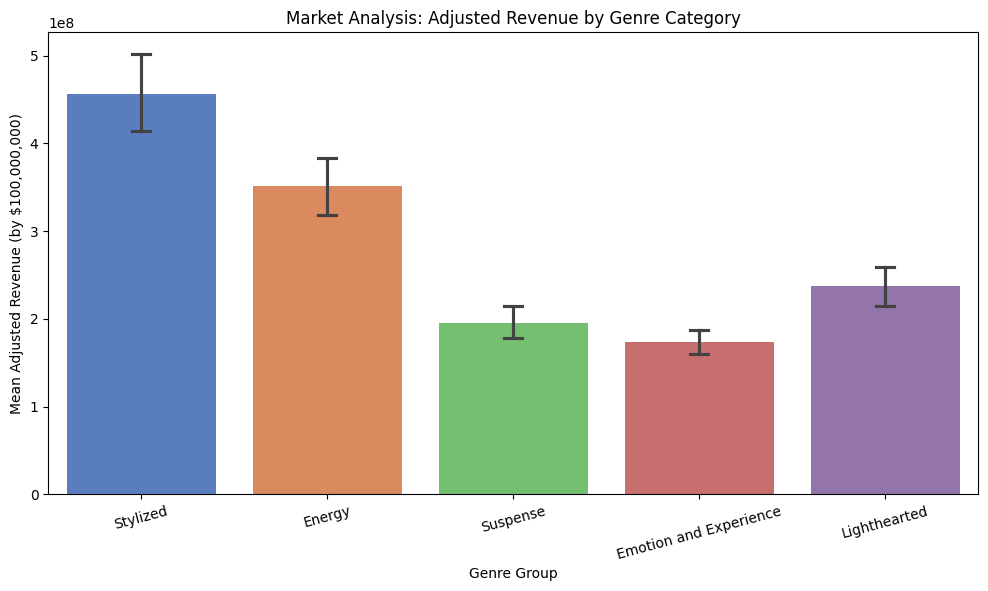

In [ ]:
# explode genres
exploded_movies = merged_movies.explode('genres')

# print counts
group_sizes = exploded_movies['genres'].value_counts()

for genre, count in group_sizes.items():
    print(f"Genre Category: {genre:<25} | Number of Movies: {count}")

# drop rows with missing genres or revenue
analysis_df = exploded_movies.dropna(subset=['genres', 'revenue_adjusted'])

# we run the ANOVA
genre_labels = analysis_df['genres'].unique()
groups = [analysis_df[analysis_df['genres'] == g]['revenue_adjusted'] for g in genre_labels]
f_stat, p_value = stats.f_oneway(*groups)

# resulting data
print(f"ANOVA F-Statistic: {f_stat:.4f}")
print(f"ANOVA P-Value: {p_value:.4e}")

# plotted results for the ANOVA
plt.figure(figsize=(12, 6))
sns.barplot(data=analysis_df, x='genres', y='revenue_adjusted', capsize=0.1, palette='muted', hue='genres')
plt.title('Market Analysis: Adjusted Revenue by Genre Category')
plt.ylabel('Mean Adjusted Revenue (by $100,000,000)')
plt.xlabel('Genre Group')
plt.xticks(rotation=15)
plt.show()

With a p-value of $1.46 \times 10^{-60}$, which is far below our significance level of $\alpha = 0.05$, we find statistically significant evidence to reject the null hypothesis. We conclude that the mean Worldwide Revenue is not uniform across the five genre groups  
($\mu_{Energy} = \mu_{Suspense} = \mu_{Stylized} = \mu_{Emotion} = \mu_{Lighthearted}$). By accepting the alternative hypothesis, we confirm that at least one genre significantly outperforms the others financially. As seen in the bar chart, the Stylized and Energy categories earn substantially higher mean revenues compared to Suspense, Emotion & Experience, and Lighthearted films. This suggests that high-concept, visual-heavy, and high-action productions remain the primary drivers of box office scale.

## **Primary Analysis**